**Install & Import Libraries**

In [21]:
!pip install catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00


**Upload ZIP File**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Home credit risk.zip to Home credit risk.zip


**Extract ZIP**

In [4]:
import zipfile
import os

zip_path = '/content/Home credit risk.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('data')

print(os.listdir('data'))

['bureau.csv', 'credit_card_balance.csv', 'installments_payments.csv', 'HomeCredit_columns_description.csv', 'POS_CASH_balance.csv', 'home-credit-default-risk', 'previous_application.csv', 'bureau_balance.csv']


**Load CSV Files**

In [11]:
import pandas as pd

app = pd.read_csv('/content/data/home-credit-default-risk/application_train.csv')

bureau = pd.read_csv('/content/data/bureau.csv')
previous = pd.read_csv('/content/data/previous_application.csv')
installments = pd.read_csv('/content/data/installments_payments.csv')

**Aggregate & Merge**

In [13]:
bureau_agg = bureau.groupby('SK_ID_CURR').mean(numeric_only=True).reset_index()
previous_agg = previous.groupby('SK_ID_CURR').mean(numeric_only=True).reset_index()
installments_agg = installments.groupby('SK_ID_CURR').mean(numeric_only=True).reset_index()

df = app.merge(bureau_agg, on='SK_ID_CURR', how='left')
df = df.merge(previous_agg, on='SK_ID_CURR', how='left')
df = df.merge(installments_agg, on='SK_ID_CURR', how='left')

**Handle Missing Values**

In [14]:
df = df.fillna(df.median(numeric_only=True))

**Encode Categorical Variables**

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

**Features & Target**

In [17]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

**Train-Test Split**

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

**Logistic Regression**

In [22]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_probs = lr.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**CatBoost Model**

In [23]:
cat = CatBoostClassifier(verbose=0)
cat.fit(X_train, y_train)

cat_probs = cat.predict_proba(X_test)[:,1]

**Business Cost Function**

In [24]:
def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (fn * 1000) + (fp * 200)

**Threshold Optimization**

In [25]:
thresholds = np.arange(0.1, 0.9, 0.05)

best_cost = float('inf')
best_threshold = 0

for t in thresholds:
    preds = (cat_probs >= t).astype(int)
    cost = business_cost(y_test, preds)

    if cost < best_cost:
        best_cost = cost
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Minimum Cost:", best_cost)

Best Threshold: 0.15000000000000002
Minimum Cost: 8175400


**Final Predictions**

In [26]:
final_preds = (cat_probs >= best_threshold).astype(int)

print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.95      0.89      0.92    113119
           1       0.25      0.43      0.32      9886

    accuracy                           0.85    123005
   macro avg       0.60      0.66      0.62    123005
weighted avg       0.89      0.85      0.87    123005



**Cost vs Threshold Plot**

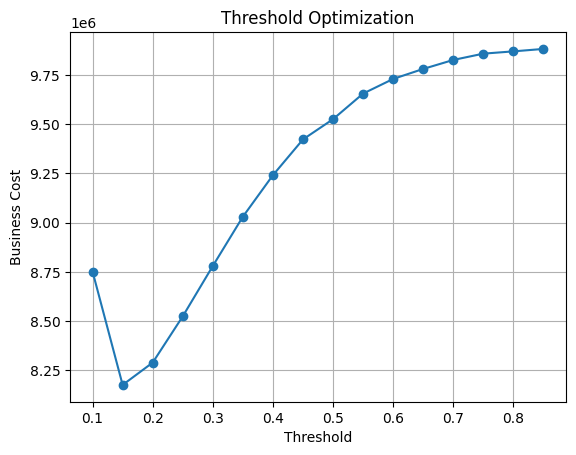

In [27]:
costs = []

for t in thresholds:
    preds = (cat_probs >= t).astype(int)
    costs.append(business_cost(y_test, preds))

plt.plot(thresholds, costs, marker='o')
plt.xlabel('Threshold')
plt.ylabel('Business Cost')
plt.title('Threshold Optimization')
plt.grid(True)
plt.show()